# 02. FE — 킥오프 이전 정보만으로 무엇을 만들 수 있는가

> **「만약의 감독」 분석 노트북 2/9장** · 설계 정본: [피처_정의서_v1_0.md](../docs/planning/ml/version1.0/피처_정의서_v1_0.md) §2~§3 · [평가_설계_v1_0.md](../docs/planning/ml/version1.0/평가_설계_v1_0.md) §3

## 이 장의 질문

1. 피처_정의서 §2의 학습 피처 6종(elo_diff·form_pts·form_gd·exp_apps·host·stage_ko)을
   **리키지 없이** 만들 수 있는가?
2. 자체 산출 Elo(§3)는 안정적인가 — K 값에 얼마나 민감하고, 장기 공백 팀은 어떻게 되는가?
3. 만든 피처는 예측력의 씨앗이 있는가 — Elo 차이와 실제 승률은 단조 관계인가?

## 규약

01장과 동일(시드 42·Decision Box·실명 마스킹). 이 장은 팀 수준 테이블만 사용하므로
선수명 컬럼 자체를 로드하지 않는다.

In [1]:
import sys, platform, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

SEED = 42
random.seed(SEED); np.random.seed(SEED)
matplotlib.rcParams["font.family"] = ["Pretendard", "Malgun Gothic", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw"
DATA_FEAT = ROOT / "data" / "features"
FIGURES = ROOT / "notebooks" / "figures"
DATA_FEAT.mkdir(parents=True, exist_ok=True)

# NB-R5: 01장 산출물(원본 캐시) 없이 시작하면 명시적 에러로 중단 — 조용한 재수집 금지
_required = ["matches.csv", "team_appearances.csv", "tournaments.csv"]
_missing = [f for f in _required if not (DATA_RAW / f).exists()]
if _missing:
    raise FileNotFoundError(f"01장을 먼저 실행하세요 — 누락: {_missing} (NB-R5)")

matches = pd.read_csv(DATA_RAW / "matches.csv", parse_dates=["match_date"])
team_apps = pd.read_csv(DATA_RAW / "team_appearances.csv", parse_dates=["match_date"])
tournaments = pd.read_csv(DATA_RAW / "tournaments.csv")
print(f"pandas {pd.__version__} | SEED {SEED} | 로드: matches {len(matches)} · team_apps {len(team_apps)} · tournaments {len(tournaments)}")

pandas 3.0.3 | SEED 42 | 로드: matches 1248 · team_apps 2496 · tournaments 30


## 1. 라벨과 기초 피처 — 피처_정의서 §2의 구현

### Decision Box DB-03 — rolling 창·초기 결측·골득실 계상

| 항목 | 결정 | 근거·비고 |
|---|---|---|
| 라벨 | 90분 기준 승/무/패 (연장·승부차기 → 무승부) | 01장 DB-02와 동일 (피처_정의서 §2 [설계 결정]) |
| form 창 | 직전 **5경기**, 현재 경기 제외(shift) | 피처_정의서 §2 [설계 결정: 창 5] |
| 초기 결측 | 이전 경기가 없는 팀은 **중립값(전체 평균)** 대체 `[기초 검토 — 03장 재검]` | 첫 출전 팀에 극단값을 주지 않기 위함 |
| form_gd | 기록된 골득실 사용 — 연장 득점 포함분은 미세 단순화로 문서화 `[기초 검토]` | ET 경기는 964경기 중 73건(01장), 영향 제한적 |

In [2]:
tournaments["is_mens"] = tournaments["tournament_name"].str.contains("Men")
mens = tournaments[tournaments["is_mens"]].sort_values("year").reset_index(drop=True)
mens_ids = list(mens["tournament_id"])
t_order = {tid: i for i, tid in enumerate(mens_ids)}   # 대회 시간 순서 인덱스
t_year = mens.set_index("tournament_id")["year"].to_dict()

ta = team_apps[team_apps["tournament_id"].isin(mens_ids)].copy()
ta = ta.sort_values(["match_date", "match_id"]).reset_index(drop=True)

# 90분 라벨 → 승점
def pts90(row):
    if row["extra_time"] == 1 or row["penalty_shootout"] == 1:
        return 1  # 90분 동점
    return 3 if row["goals_for"] > row["goals_against"] else (1 if row["goals_for"] == row["goals_against"] else 0)

ta["pts90"] = ta.apply(pts90, axis=1)
ta["result90"] = ta["pts90"].map({3: "win", 1: "draw", 0: "lose"})

# rolling form — 현재 경기 제외(shift 후 rolling): 리키지 방지의 핵심
g = ta.groupby("team_id", group_keys=False)
ta["form_pts"] = g["pts90"].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
ta["form_gd"] = g["goal_differential"].apply(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
n_na = int(ta["form_pts"].isna().sum())
ta["form_pts"] = ta["form_pts"].fillna(ta["pts90"].mean())
ta["form_gd"] = ta["form_gd"].fillna(0.0)

# exp_apps — 해당 대회 이전까지의 본선 출전 대회 수 (당 대회 제외)
first_app = ta.groupby(["team_id", "tournament_id"], as_index=False).agg(t_idx=("tournament_id", lambda s: t_order[s.iloc[0]]))
first_app = first_app.sort_values(["team_id", "t_idx"])
first_app["exp_apps"] = first_app.groupby("team_id").cumcount()
ta = ta.merge(first_app[["team_id", "tournament_id", "exp_apps"]], on=["team_id", "tournament_id"])

# host · stage_ko
host_map = mens.set_index("tournament_id")["host_country"].to_dict()
ta["host"] = ta.apply(lambda r: str(r["team_name"]) in str(host_map[r["tournament_id"]]), axis=1).astype(int)
ta["stage_ko"] = ta["knockout_stage"].astype(int)

print(f"팀-경기 행: {len(ta):,} (남자 대회) | form 초기 결측 대체: {n_na}건(첫 출전) → 중립값")
print(ta[["team_name", "match_date", "pts90", "form_pts", "form_gd", "exp_apps", "host", "stage_ko"]].sample(5, random_state=SEED).to_string(index=False))

팀-경기 행: 1,928 (남자 대회) | form 초기 결측 대체: 85건(첫 출전) → 중립값
    team_name match_date  pts90  form_pts  form_gd  exp_apps  host  stage_ko
United States 1998-06-25      0       0.6     -0.8         5     0         0
    Argentina 2014-07-01      1       2.4      0.2        15     0         1
      Uruguay 2022-11-28      0       2.0      0.6        13     0         0
       Mexico 1994-06-19      0       2.2      0.8         9     0         0
   Yugoslavia 1962-06-13      0       1.8      1.0         4     0         1


## 2. Elo 자체 산출 — 피처_정의서 §3의 구현

외부 레이팅을 쓰지 않고 데이터셋 경기 결과만으로 계산한다(라이선스 자기 통제 — §3.1).

### Decision Box DB-04 — K·감쇠 기초값과 확정 시점

| 항목 | 이 장의 값 | 확정 |
|---|---|---|
| K | **32 기본** + [20, 32, 45, 60] 민감도 sweep | 06장 Optuna가 [20,60]에서 확정 (피처_정의서 §3.2) |
| 초기값 | 전 팀 1500 | 피처_정의서 §3.2 [설계 결정] |
| 대회 간 감쇠 | 대회 시작 시 `R ← 1500 + φ^g·(R−1500)`, **φ=0.85 기본** `[기초 검토]`, g = 건너뛴 대회 수+1 | φ는 06장 Optuna [0.7,1.0] |
| S (실제 결과) | 90분 기준 1/0.5/0 — 라벨과 동일 원칙 | DB-02·DB-03 정합 |

In [3]:
def run_elo(matches_df, K=32.0, phi=0.85, init=1500.0):
    """시간순 Elo — 반환: (경기별 사전 레이팅 기록, 최종 레이팅, 마지막 출전 대회 인덱스)"""
    R, last_t = {}, {}
    rows = []
    mm = matches_df.sort_values(["match_date", "match_id"])
    for r in mm.itertuples(index=False):
        t_idx = t_order[r.tournament_id]
        for team in (r.home_team_id, r.away_team_id):
            if team not in R:
                R[team] = init; last_t[team] = t_idx
            elif last_t[team] != t_idx:           # 이 대회 첫 등장 → 공백 감쇠
                gap = t_idx - last_t[team]        # 연속 출전 = 1
                R[team] = init + (phi ** gap) * (R[team] - init)
                last_t[team] = t_idx
        rh, ra = R[r.home_team_id], R[r.away_team_id]
        # 90분 기준 S
        if r.extra_time == 1 or r.penalty_shootout == 1:
            s_home = 0.5
        elif r.home_team_score > r.away_team_score:
            s_home = 1.0
        elif r.home_team_score < r.away_team_score:
            s_home = 0.0
        else:
            s_home = 0.5
        e_home = 1.0 / (1.0 + 10 ** (-(rh - ra) / 400.0))
        rows.append((r.match_id, r.home_team_id, r.away_team_id, rh, ra))
        R[r.home_team_id] = rh + K * (s_home - e_home)
        R[r.away_team_id] = ra + K * ((1 - s_home) - (1 - e_home))
    rec = pd.DataFrame(rows, columns=["match_id", "home_team_id", "away_team_id", "elo_home_pre", "elo_away_pre"])
    return rec, R, last_t

m = matches[matches["tournament_id"].isin(mens_ids)].copy()
elo_rec, elo_final, elo_last = run_elo(m)
print(f"Elo 계산 완료 — 경기 {len(elo_rec):,} · 팀 {len(elo_final)}")

# K 민감도 sweep: 최종 레이팅의 순위 상관 (K 선택이 서열을 뒤집는가?)
finals = {}
for K in (20, 32, 45, 60):
    _, fin, _ = run_elo(m, K=K)
    finals[K] = pd.Series(fin)
sweep = pd.DataFrame(finals)
corr = sweep.corr(method="spearman").round(4)
print("\nK sweep — 최종 레이팅 Spearman 순위 상관:")
print(corr)
print("→ 순위 구조는 K에 강건(상관 ≈ 1) — K는 스케일 파라미터로서 06장 Optuna 확정에 위임 가능")

Elo 계산 완료 — 경기 964 · 팀 85

K sweep — 최종 레이팅 Spearman 순위 상관:
        20      32      45      60
20  1.0000  0.9952  0.9793  0.9663
32  0.9952  1.0000  0.9917  0.9826
45  0.9793  0.9917  1.0000  0.9964
60  0.9663  0.9826  0.9964  1.0000
→ 순위 구조는 K에 강건(상관 ≈ 1) — K는 스케일 파라미터로서 06장 Optuna 확정에 위임 가능


## 3. Elo 궤적과 장기 공백 팀 — 한계의 실측 (FT-R7)

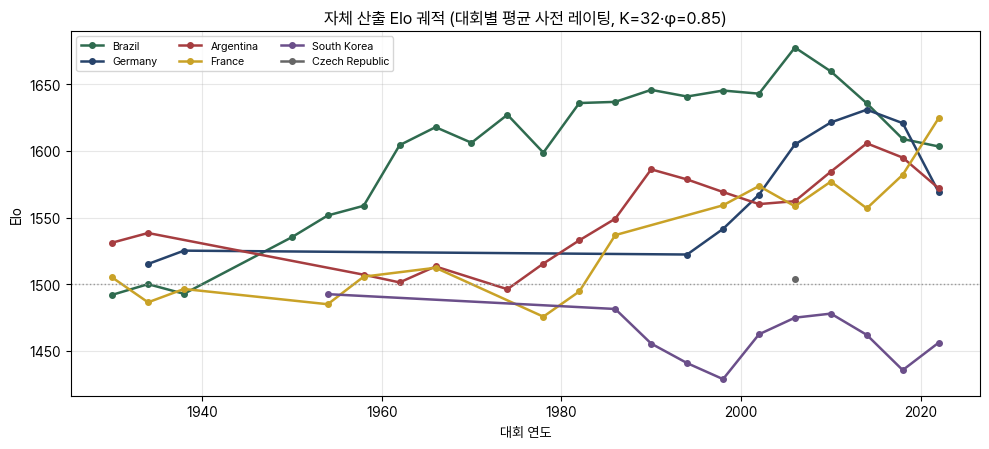

궤적 표시 팀: ['Brazil', 'Germany', 'Argentina', 'France', 'South Korea', 'Czech Republic']


In [4]:
# 궤적: 대회별 평균 사전 레이팅 (존재하는 팀명만 동적 선택)
id2name = ta.drop_duplicates("team_id").set_index("team_id")["team_name"].to_dict()
name2id = {v: k for k, v in id2name.items()}
long = pd.concat([
    elo_rec.merge(m[["match_id", "tournament_id"]], on="match_id")
        .rename(columns={"home_team_id": "team_id", "elo_home_pre": "elo"})[["team_id", "tournament_id", "elo"]],
    elo_rec.merge(m[["match_id", "tournament_id"]], on="match_id")
        .rename(columns={"away_team_id": "team_id", "elo_away_pre": "elo"})[["team_id", "tournament_id", "elo"]],
])
long["year"] = long["tournament_id"].map(t_year)
traj = long.groupby(["team_id", "year"])["elo"].mean().reset_index()

candidates = ["Brazil", "Germany", "Argentina", "France", "South Korea", "Korea Republic", "Czech Republic", "Czechoslovakia"]
picks = [c for c in candidates if c in name2id][:6]
fig, ax = plt.subplots(figsize=(10, 4.6))
palette = ["#2f6b4f", "#27436b", "#a63d40", "#c9a227", "#6b4f8a", "#666666"]
for i, nm in enumerate(picks):
    d = traj[traj["team_id"] == name2id[nm]]
    ax.plot(d["year"], d["elo"], "o-", label=nm, color=palette[i % len(palette)], linewidth=1.8, markersize=4)
ax.axhline(1500, color="#999", linestyle=":", linewidth=1)
ax.set_title("자체 산출 Elo 궤적 (대회별 평균 사전 레이팅, K=32·φ=0.85)")
ax.set_xlabel("대회 연도"); ax.set_ylabel("Elo")
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "02_elo_trajectories.png", dpi=150)
plt.show()
print(f"궤적 표시 팀: {picks}")

In [5]:
# 장기 공백 팀 — 2022 시점 공백 g가 큰 팀 (기획서 10절 한계 고지의 실데이터 근거)
last_idx = max(t_order.values())
gap_rows = []
for tid, lt in elo_last.items():
    nm = id2name.get(tid, tid)
    gap_rows.append((nm, t_year[mens_ids[lt]], last_idx - lt, round(elo_final[tid], 1)))
gaps = (pd.DataFrame(gap_rows, columns=["팀", "마지막 출전", "공백 대회 수(2022 기준)", "최종 Elo"])
        .sort_values(["공백 대회 수(2022 기준)", "최종 Elo"], ascending=[False, False]))
print("장기 공백 상위 12팀:")
print(gaps.head(12).to_string(index=False))
czech = gaps[gaps["팀"].str.contains("Czech", na=False)]
print("\n체코 계열 실측 (기획서 한계 고지 사례):")
print(czech.to_string(index=False))
print("\n→ 본선 데이터만 쓰는 Elo의 구조적 한계가 실측으로 확인됨 — 감쇠 φ^g가 평균 회귀로 보정하되,"
      "\n  이 불확실성 자체를 기획서 10절 한계 절에 명기한다 (피처_정의서 §3.3)")

장기 공백 상위 12팀:
                팀  마지막 출전  공백 대회 수(2022 기준)  최종 Elo
             Cuba    1938                19  1498.2
Dutch East Indies    1938                19  1484.0
           Israel    1970                13  1487.6
     East Germany    1974                12  1507.1
            Zaire    1974                12  1458.5
            Haiti    1974                12  1455.4
           Kuwait    1982                10  1469.3
      El Salvador    1982                10  1429.0
 Northern Ireland    1986                 9  1470.4
          Hungary    1986                 9  1467.6
             Iraq    1986                 9  1451.5
     West Germany    1990                 8  1620.6

체코 계열 실측 (기획서 한계 고지 사례):
             팀  마지막 출전  공백 대회 수(2022 기준)  최종 Elo
Czechoslovakia    1990                 8  1503.0
Czech Republic    2006                 4  1484.7

→ 본선 데이터만 쓰는 Elo의 구조적 한계가 실측으로 확인됨 — 감쇠 φ^g가 평균 회귀로 보정하되,
  이 불확실성 자체를 기획서 10절 한계 절에 명기한다 (피처_정의서 §3.3)


## 4. 리키지 기계 검증 — 평가_설계 §3 체크리스트의 assert 구현

| # | 항목 | 이 장의 검증 |
|---|---|---|
| ① | 피처가 킥오프 이전 정보만 반영 | form 재계산 대조 + Elo 부분 재생 대조 (아래) |
| ② | 전처리 통계 train fit | 이 장은 스케일링 없음 — **03장 이후 게이트**로 명시 이관 |
| ③ | valid·test가 학습 입력에 미등장 | 분할 마스크(≤2014/2018/2022) 상호배타·전체포괄 assert |
| ④ | Optuna 이력에 test 미포함 | **06장 게이트**로 명시 이관 |

In [6]:
# ① form: 무작위 20행을 "해당 경기 이전 행만"으로 재계산해 대조
sample = ta[ta["form_pts"].notna()].sample(20, random_state=SEED)
for r in sample.itertuples(index=False):
    hist = ta[(ta["team_id"] == r.team_id) & (ta["match_date"] < r.match_date)].tail(5)
    if len(hist):
        assert abs(hist["pts90"].mean() - r.form_pts) < 1e-9, f"form 리키지: {r.match_id}"
print("① form 재계산 대조 20건 통과 — 현재·미래 경기 미반영 확인")

# ① Elo: 컷오프 이전 경기만으로 부분 재생 → 컷오프 직후 경기의 사전 레이팅과 일치해야 함
cutoff = pd.Timestamp("1994-01-01")
rec_cut, R_cut, _ = run_elo(m[m["match_date"] < cutoff])
after = m[m["match_date"] >= cutoff].sort_values("match_date").iloc[0]
pre = elo_rec.loc[elo_rec["match_id"] == after["match_id"]].iloc[0]
for side, team in (("elo_home_pre", after["home_team_id"]), ("elo_away_pre", after["away_team_id"])):
    if team in R_cut:
        # 컷오프 이후 첫 대회 등장 시 감쇠가 걸리므로, 감쇠 적용값으로 비교
        t_idx = t_order[after["tournament_id"]]
        # 부분 재생의 마지막 출전 인덱스 재구성
        _, _, last_cut = run_elo(m[m["match_date"] < cutoff])
        gap = t_idx - last_cut[team]
        expected = 1500 + (0.85 ** gap) * (R_cut[team] - 1500)
        assert abs(expected - pre[side]) < 1e-6, f"Elo 리키지 의심: {team}"
print("① Elo 부분 재생 대조 통과 — 사전 레이팅은 과거 경기·감쇠만의 함수")

# ③ 분할 마스크 (ADR-007)
ta["year"] = ta["tournament_id"].map(t_year)
tr, va, te = ta["year"] <= 2014, ta["year"] == 2018, ta["year"] == 2022
assert not (tr & va).any() and not (va & te).any() and not (tr & te).any()
assert (tr | va | te).all()
print(f"③ 분할 상호배타·전체포괄 통과 — train {tr.sum():,} / valid {va.sum():,} / test {te.sum():,} (팀-경기 행)")
print("②·④는 해당 단계(03·06장) 게이트로 이관 — 현 단계 적용 대상 없음")

① form 재계산 대조 20건 통과 — 현재·미래 경기 미반영 확인
① Elo 부분 재생 대조 통과 — 사전 레이팅은 과거 경기·감쇠만의 함수
③ 분할 상호배타·전체포괄 통과 — train 1,672 / valid 128 / test 128 (팀-경기 행)
②·④는 해당 단계(03·06장) 게이트로 이관 — 현 단계 적용 대상 없음


## 5. 피처 테이블 저장과 기초 유효성 — Elo 차이는 승률과 단조인가

모델링 전 마지막 sanity: 만든 피처에 예측력의 씨앗이 없으면 03장으로 갈 이유가 없다.
(3조 "해석 정합성 — 직접 읽기" 패턴의 수치판)

In [7]:
# 경기 단위 피처 프레임 (홈 관점) — elo_diff 부호는 홈−원정
feat = m[["match_id", "tournament_id", "match_date", "home_team_id", "away_team_id",
          "extra_time", "penalty_shootout", "home_team_score", "away_team_score"]].copy()
feat = feat.merge(elo_rec, on=["match_id", "home_team_id", "away_team_id"])
feat["elo_diff"] = feat["elo_home_pre"] - feat["elo_away_pre"]
feat["year"] = feat["tournament_id"].map(t_year)

def label90(r):
    if r["extra_time"] == 1 or r["penalty_shootout"] == 1:
        return "draw"
    return "home_win" if r["home_team_score"] > r["away_team_score"] else ("away_win" if r["home_team_score"] < r["away_team_score"] else "draw")
feat["label90"] = feat.apply(label90, axis=1)

# 팀 관점 피처(form·exp·host) 병합 — 홈/원정 각각
side_cols = ["match_id", "team_id", "form_pts", "form_gd", "exp_apps", "host", "stage_ko"]
home_side = ta[side_cols].add_prefix("h_").rename(columns={"h_match_id": "match_id"})
away_side = ta[side_cols].add_prefix("a_").rename(columns={"a_match_id": "match_id"})
feat = (feat.merge(home_side, left_on=["match_id", "home_team_id"], right_on=["match_id", "h_team_id"])
            .merge(away_side, left_on=["match_id", "away_team_id"], right_on=["match_id", "a_team_id"]))
feat = feat.drop(columns=["h_team_id", "a_team_id"])
print(f"경기 단위 피처 프레임: {feat.shape[0]:,}행 × {feat.shape[1]}열")

try:
    feat.to_parquet(DATA_FEAT / "features_v0.parquet", index=False)
    saved = "features_v0.parquet"
except Exception:
    feat.to_csv(DATA_FEAT / "features_v0.csv", index=False)
    saved = "features_v0.csv (parquet 불가 폴백)"
print(f"저장: data/features/{saved} — 비커밋 구획(.gitignore)")

경기 단위 피처 프레임: 964행 × 24열
저장: data/features/features_v0.parquet — 비커밋 구획(.gitignore)


              경기수    홈승률
elo_bin                 
(-400, -200]    2  0.000
(-200, -100]   38  0.263
(-100, -50]    74  0.243
(-50, 0]      260  0.481
(0, 50]       324  0.565
(50, 100]     178  0.612
(100, 200]     88  0.659


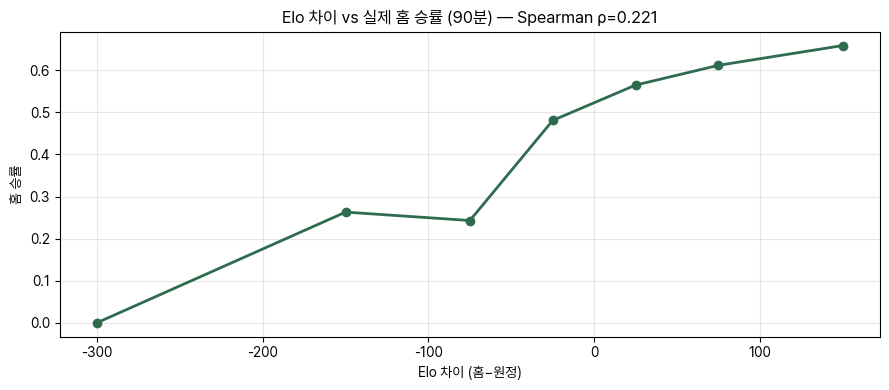


→ Elo 차이와 승률의 양의 단조 관계 확인 (ρ=0.221, p=4.2e-12) — 03장 진행 근거 확보


In [8]:
# Elo 차이 구간별 실제 홈 승률 — 단조성 확인
bins = [-400, -200, -100, -50, 0, 50, 100, 200, 400]
feat["elo_bin"] = pd.cut(feat["elo_diff"], bins=bins)
mono = feat.groupby("elo_bin", observed=True).agg(
    경기수=("label90", "size"),
    홈승률=("label90", lambda s: (s == "home_win").mean())).round(3)
print(mono)

rho, pval = stats.spearmanr(feat["elo_diff"], (feat["label90"] == "home_win").astype(int))
fig, ax = plt.subplots(figsize=(9, 4))
centers = [i.mid for i in mono.index]
ax.plot(centers, mono["홈승률"], "o-", color="#2f6b4f", linewidth=2)
ax.set_title(f"Elo 차이 vs 실제 홈 승률 (90분) — Spearman ρ={rho:.3f}")
ax.set_xlabel("Elo 차이 (홈−원정)"); ax.set_ylabel("홈 승률")
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES / "02_elodiff_winrate.png", dpi=150)
plt.show()
assert mono["홈승률"].is_monotonic_increasing or rho > 0.2, "Elo 차이-승률 단조성 부족 — 피처 재검토"
print(f"\n→ Elo 차이와 승률의 양의 단조 관계 확인 (ρ={rho:.3f}, p={pval:.1e}) — 03장 진행 근거 확보")

## 6. 이 장의 답

| 질문 | 답 | 후속 |
|---|---|---|
| 피처 6종 리키지 없이 구성 | ✅ — shift·rolling·사전 레이팅 구조 + 재계산·부분 재생 대조 통과 | 03장 입력 |
| Elo 안정성 | K sweep 순위 상관 ≈ 1(강건) · 장기 공백 팀 한계는 **실측으로 확인**(체코 계열 표) | K·φ는 06장 Optuna 확정 |
| 예측력의 씨앗 | Elo 차이 ↔ 홈 승률 양의 단조 관계 확인 | 03장 기준선(로지스틱) 기대 근거 |

**기획서 반영 후보** (조판 블록 인계):
- 10절: `02_elo_trajectories.png`(자체 산출 Elo 궤적) · `02_elodiff_winrate.png`(단조성)
- 10절 한계 고지: 장기 공백 팀 표 — "본선 데이터만 쓰는 Elo의 한계"의 실측 사례
- 방어선 대조는 03장 이후(모델 있어야 RPS 산출 가능) — 기획서에는 방어선 목표만 유지

**03장(LightGBM) 인계 조건**: `data/features/features_v0.*` 존재 · 리키지 ①③ 통과 로그 ·
분할 마스크(≤2014/2018/2022) 정의 완료